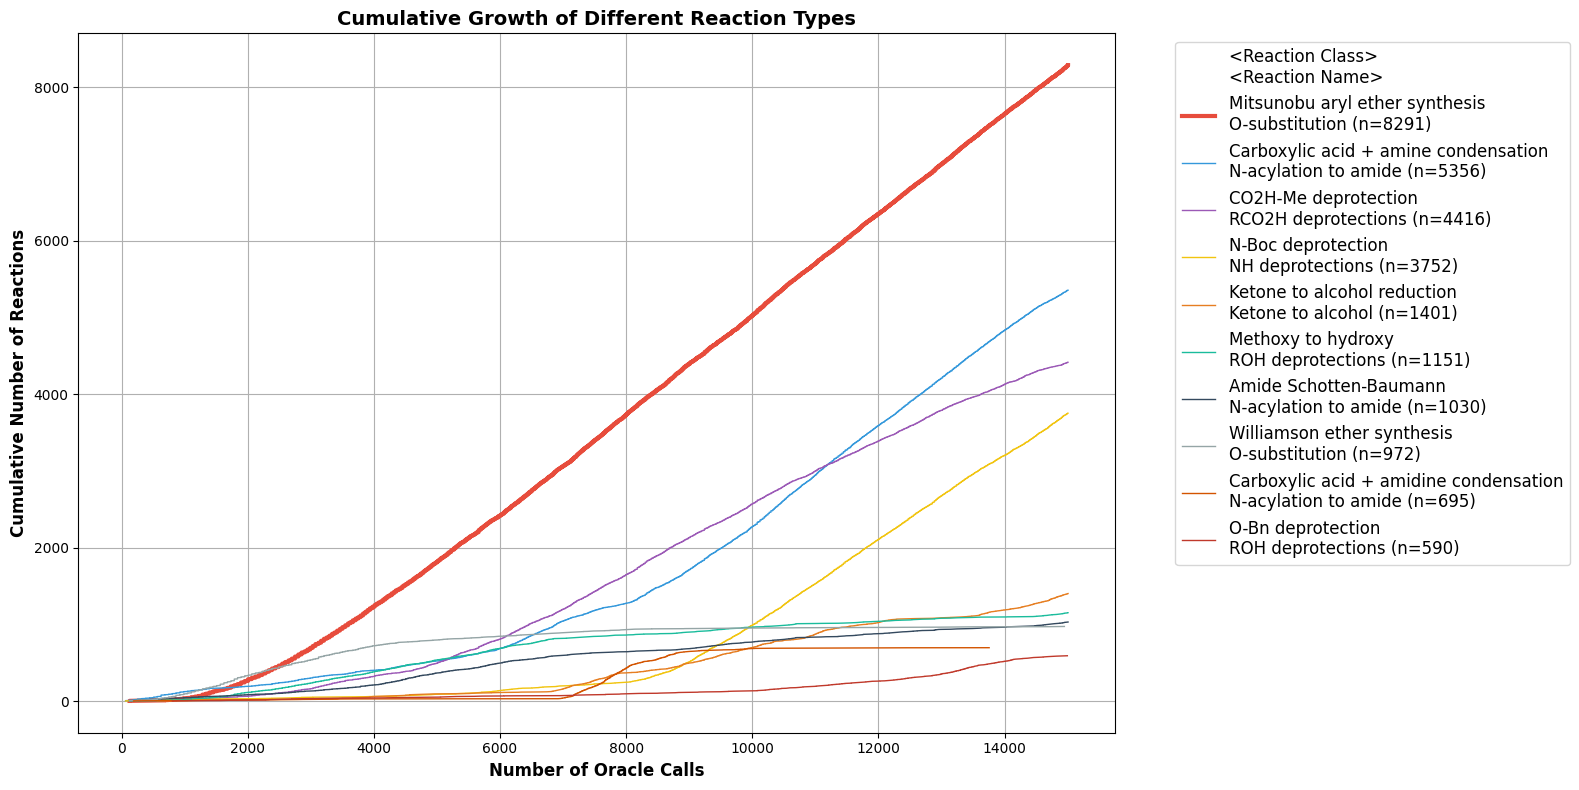

SMILES with no oracle call match: 0


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from collections import defaultdict

def canonicalize_smiles(smiles: str) -> str:
    """
    Canonicalize a SMILES string based on RDKit convention.
    """
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except Exception as e:
        return smiles

# Load data
enforced_rxn = "mitsunobu"
seed = 1
experiment_path = f"test_files/{enforced_rxn}/seed{seed}"
rxns = json.load(open(f"{experiment_path}/syntheseus_results/smiles_rxn_tracker.json"))
oracle_history = pd.read_csv(f"{experiment_path}/oracle_history.csv")
oracle_history["canonical_smiles"] = oracle_history["smiles"].apply(canonicalize_smiles)

# Track reactions by class over time
stats = defaultdict(list)
rxn_smiles = defaultdict(list)
no_match = 0

for smiles, rxn_info in rxns.items():
    try:
        oracle_call = int(oracle_history[(oracle_history["canonical_smiles"] == smiles)]["oracle_calls"].values[0])
    except IndexError:
        no_match += 1
        oracle_call = None
        
    for depth, info in rxn_info.items():
        rxn_class = info["rxn_class"]
        rxn_name = info["rxn_name"]
            
        if oracle_call is not None and rxn_class != "Unrecognized":
            stats[(rxn_class, rxn_name)].append(oracle_call)
            rxn_smiles[(rxn_class, rxn_name)].append(info["rxn_smiles"])

# Sort each reaction class by oracle calls
for rxn_class_name in stats:
    stats[rxn_class_name] = sorted(stats[rxn_class_name])

# Sort reaction classes by count in descending order
sorted_stats = sorted(stats.items(), key=lambda x: len(x[1]), reverse=True)

# Filter for reactions with count > 500 and take top 10
sorted_stats = [(k,v) for k,v in sorted_stats if len(v) > 500][:10]

# Define color palette - using a mix of muted and vibrant colors
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', 
          '#1abc9c', '#34495e', '#95a5a6', '#d35400', '#c0392b']
enforced_color = '#e74c3c'  # Bright red for enforced reaction

# Plot cumulative reactions over time
plt.figure(figsize=(16,8))

# Add legend entry explaining format
plt.plot([], [], ' ', label='<Reaction Class>\n<Reaction Name>')

# Plot filtered reaction classes
for i, ((rxn_class, rxn_name), calls) in enumerate(sorted_stats):
    if enforced_rxn.lower() in rxn_class.lower() or enforced_rxn.lower() in rxn_name.lower():
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=enforced_color, alpha=1.0, linewidth=3)
    else:
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=colors[i], alpha=1.0, linewidth=1)

plt.xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
plt.ylabel("Cumulative Number of Reactions", fontsize=12, fontweight="bold")
plt.title("Cumulative Growth of Different Reaction Types", fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

print(f"SMILES with no oracle call match: {no_match}")


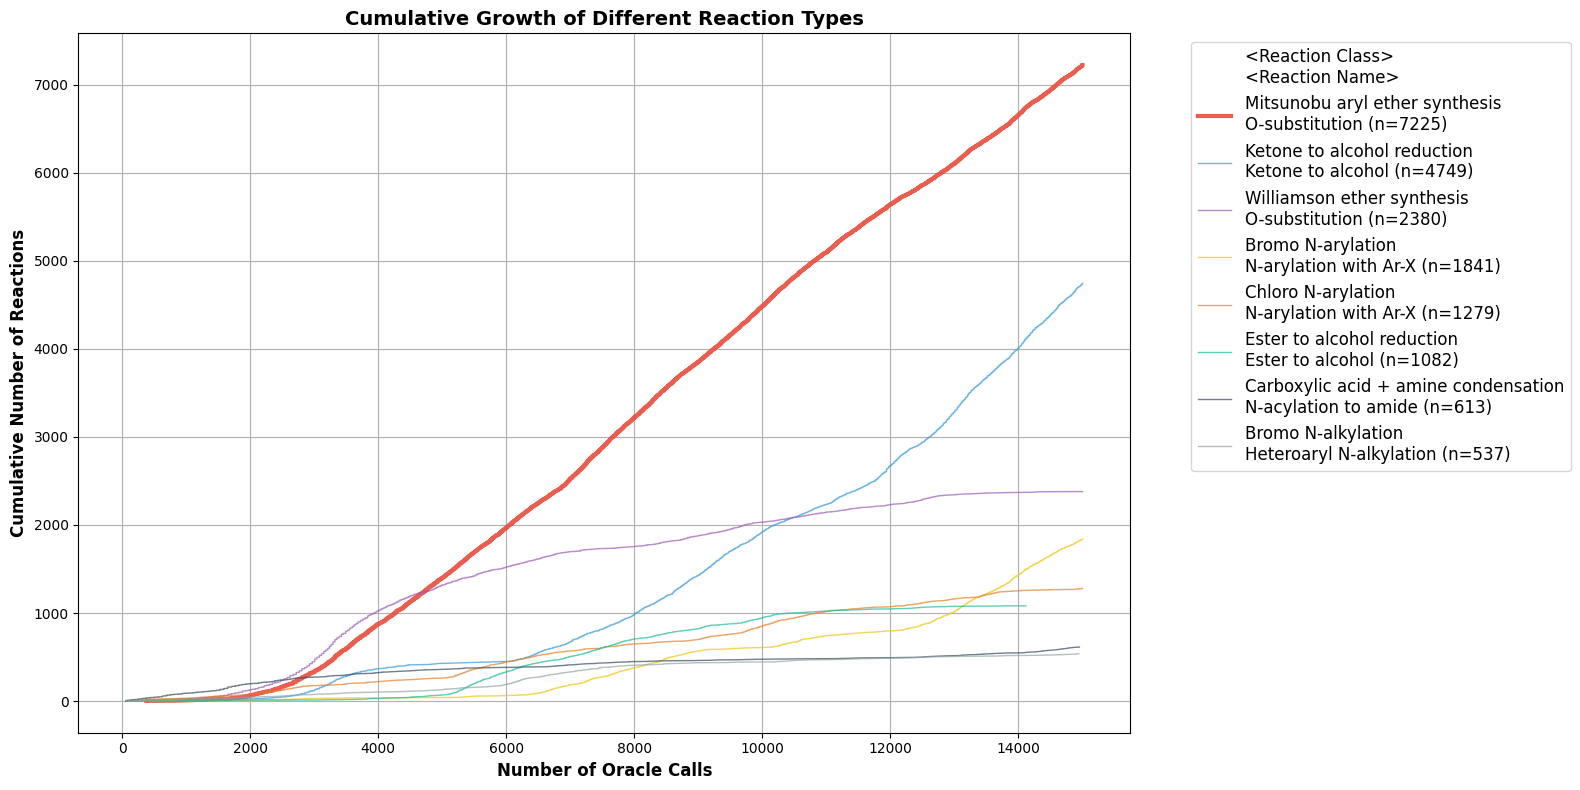

SMILES with no oracle call match: 0


In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from collections import defaultdict

def canonicalize_smiles(smiles: str) -> str:
    """
    Canonicalize a SMILES string based on RDKit convention.
    """
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except Exception as e:
        return smiles

# Load data
enforced_rxn = "mitsunobu"
seed = 0
experiment_path = f"test_files/{enforced_rxn}-avoid-deprotection/seed{seed}"
rxns = json.load(open(f"{experiment_path}/syntheseus_results/smiles_rxn_tracker.json"))
oracle_history = pd.read_csv(f"{experiment_path}/oracle_history.csv")
oracle_history["canonical_smiles"] = oracle_history["smiles"].apply(canonicalize_smiles)

# Track reactions by class over time
stats = defaultdict(list)
rxn_smiles = defaultdict(list)
no_match = 0

for smiles, rxn_info in rxns.items():
    try:
        oracle_call = int(oracle_history[(oracle_history["canonical_smiles"] == smiles)]["oracle_calls"].values[0])
    except IndexError:
        no_match += 1
        oracle_call = None
        
    for depth, info in rxn_info.items():
        rxn_class = info["rxn_class"]
        rxn_name = info["rxn_name"]
            
        if oracle_call is not None and rxn_class != "Unrecognized":
            stats[(rxn_class, rxn_name)].append(oracle_call)
            rxn_smiles[(rxn_class, rxn_name)].append(info["rxn_smiles"])

# Sort each reaction class by oracle calls
for rxn_class_name in stats:
    stats[rxn_class_name] = sorted(stats[rxn_class_name])

# Sort reaction classes by count in descending order
sorted_stats = sorted(stats.items(), key=lambda x: len(x[1]), reverse=True)

# Filter for reactions with count > 500 and take top 10
sorted_stats = [(k,v) for k,v in sorted_stats if len(v) > 500][:10]

# Define color palette - using a mix of muted and vibrant colors
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', 
          '#1abc9c', '#34495e', '#95a5a6', '#d35400', '#c0392b']
enforced_color = '#e74c3c'  # Bright red for enforced reaction

# Plot cumulative reactions over time
plt.figure(figsize=(16,8))

# Add legend entry explaining format
plt.plot([], [], ' ', label='<Reaction Class>\n<Reaction Name>')

# Plot filtered reaction classes
for i, ((rxn_class, rxn_name), calls) in enumerate(sorted_stats):
    if enforced_rxn.lower() in rxn_class.lower() or enforced_rxn.lower() in rxn_name.lower():
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=enforced_color, alpha=0.9, linewidth=3)
    else:
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=colors[i], alpha=0.7, linewidth=1)

plt.xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
plt.ylabel("Cumulative Number of Reactions", fontsize=12, fontweight="bold")
plt.title("Cumulative Growth of Different Reaction Types", fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

print(f"SMILES with no oracle call match: {no_match}")


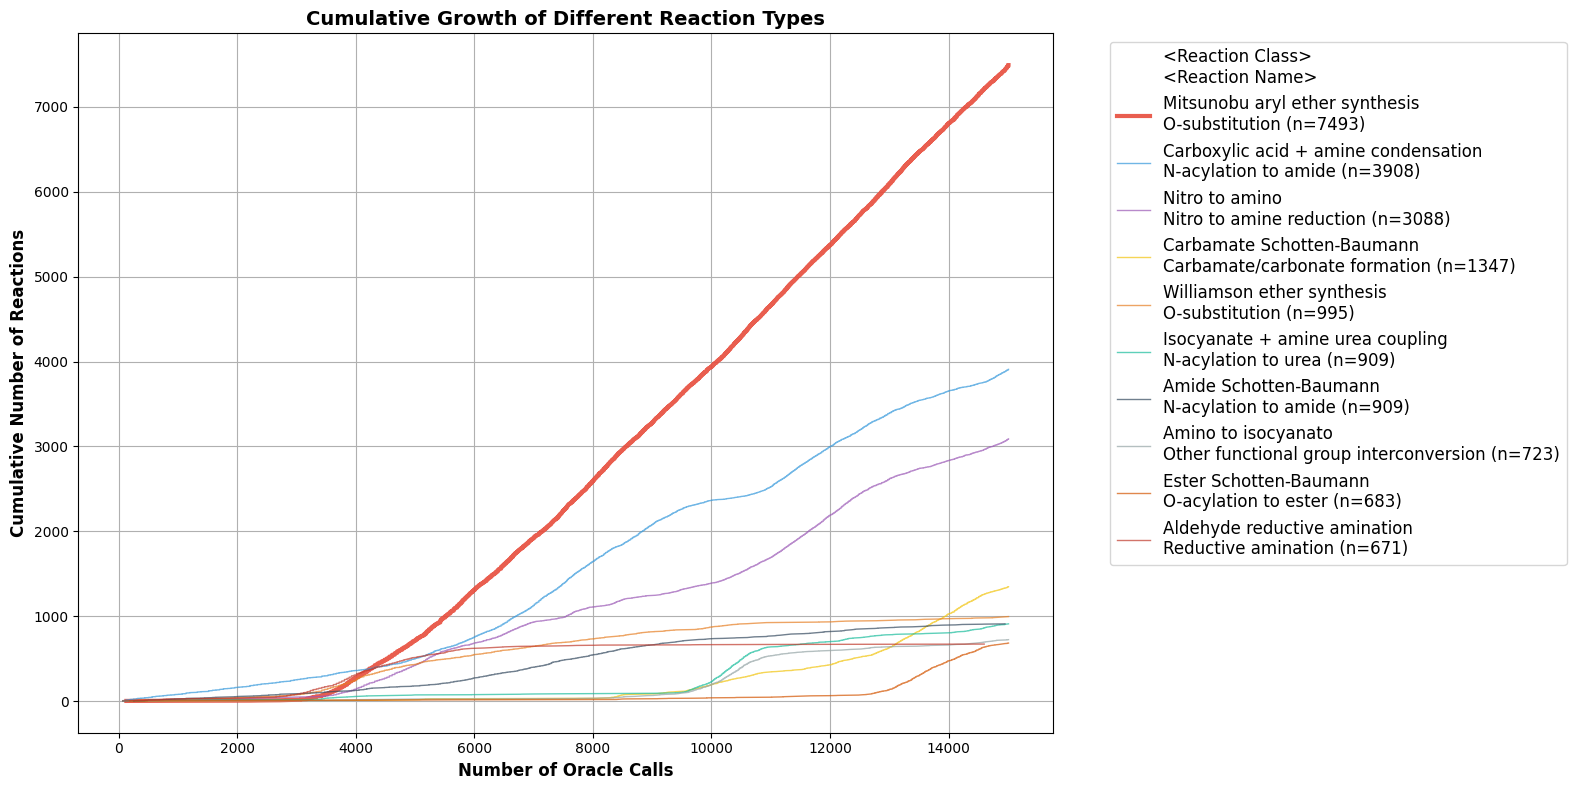

SMILES with no oracle call match: 0


In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from collections import defaultdict

def canonicalize_smiles(smiles: str) -> str:
    """
    Canonicalize a SMILES string based on RDKit convention.
    """
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except Exception as e:
        return smiles

# Load data
enforced_rxn = "mitsunobu"
seed = 2
experiment_path = f"test_files/{enforced_rxn}-avoid-deprotection/seed{seed}"
rxns = json.load(open(f"{experiment_path}/syntheseus_results/smiles_rxn_tracker.json"))
oracle_history = pd.read_csv(f"{experiment_path}/oracle_history.csv")
oracle_history["canonical_smiles"] = oracle_history["smiles"].apply(canonicalize_smiles)

# Track reactions by class over time
stats = defaultdict(list)
rxn_smiles = defaultdict(list)
no_match = 0

for smiles, rxn_info in rxns.items():
    try:
        oracle_call = int(oracle_history[(oracle_history["canonical_smiles"] == smiles)]["oracle_calls"].values[0])
    except IndexError:
        no_match += 1
        oracle_call = None
        
    for depth, info in rxn_info.items():
        rxn_class = info["rxn_class"]
        rxn_name = info["rxn_name"]
            
        if oracle_call is not None and rxn_class != "Unrecognized":
            stats[(rxn_class, rxn_name)].append(oracle_call)
            rxn_smiles[(rxn_class, rxn_name)].append(info["rxn_smiles"])

# Sort each reaction class by oracle calls
for rxn_class_name in stats:
    stats[rxn_class_name] = sorted(stats[rxn_class_name])

# Sort reaction classes by count in descending order
sorted_stats = sorted(stats.items(), key=lambda x: len(x[1]), reverse=True)

# Filter for reactions with count > 500 and take top 10
sorted_stats = [(k,v) for k,v in sorted_stats if len(v) > 500][:10]

# Define color palette - using a mix of muted and vibrant colors
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', 
          '#1abc9c', '#34495e', '#95a5a6', '#d35400', '#c0392b']
enforced_color = '#e74c3c'  # Bright red for enforced reaction

# Plot cumulative reactions over time
plt.figure(figsize=(16,8))

# Add legend entry explaining format
plt.plot([], [], ' ', label='<Reaction Class>\n<Reaction Name>')

# Plot filtered reaction classes
for i, ((rxn_class, rxn_name), calls) in enumerate(sorted_stats):
    if enforced_rxn.lower() in rxn_class.lower() or enforced_rxn.lower() in rxn_name.lower():
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=enforced_color, alpha=0.9, linewidth=3)
    else:
        plt.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=colors[i], alpha=0.7, linewidth=1)

plt.xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
plt.ylabel("Cumulative Number of Reactions", fontsize=12, fontweight="bold")
plt.title("Cumulative Growth of Different Reaction Types", fontsize=14, fontweight="bold")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

print(f"SMILES with no oracle call match: {no_match}")



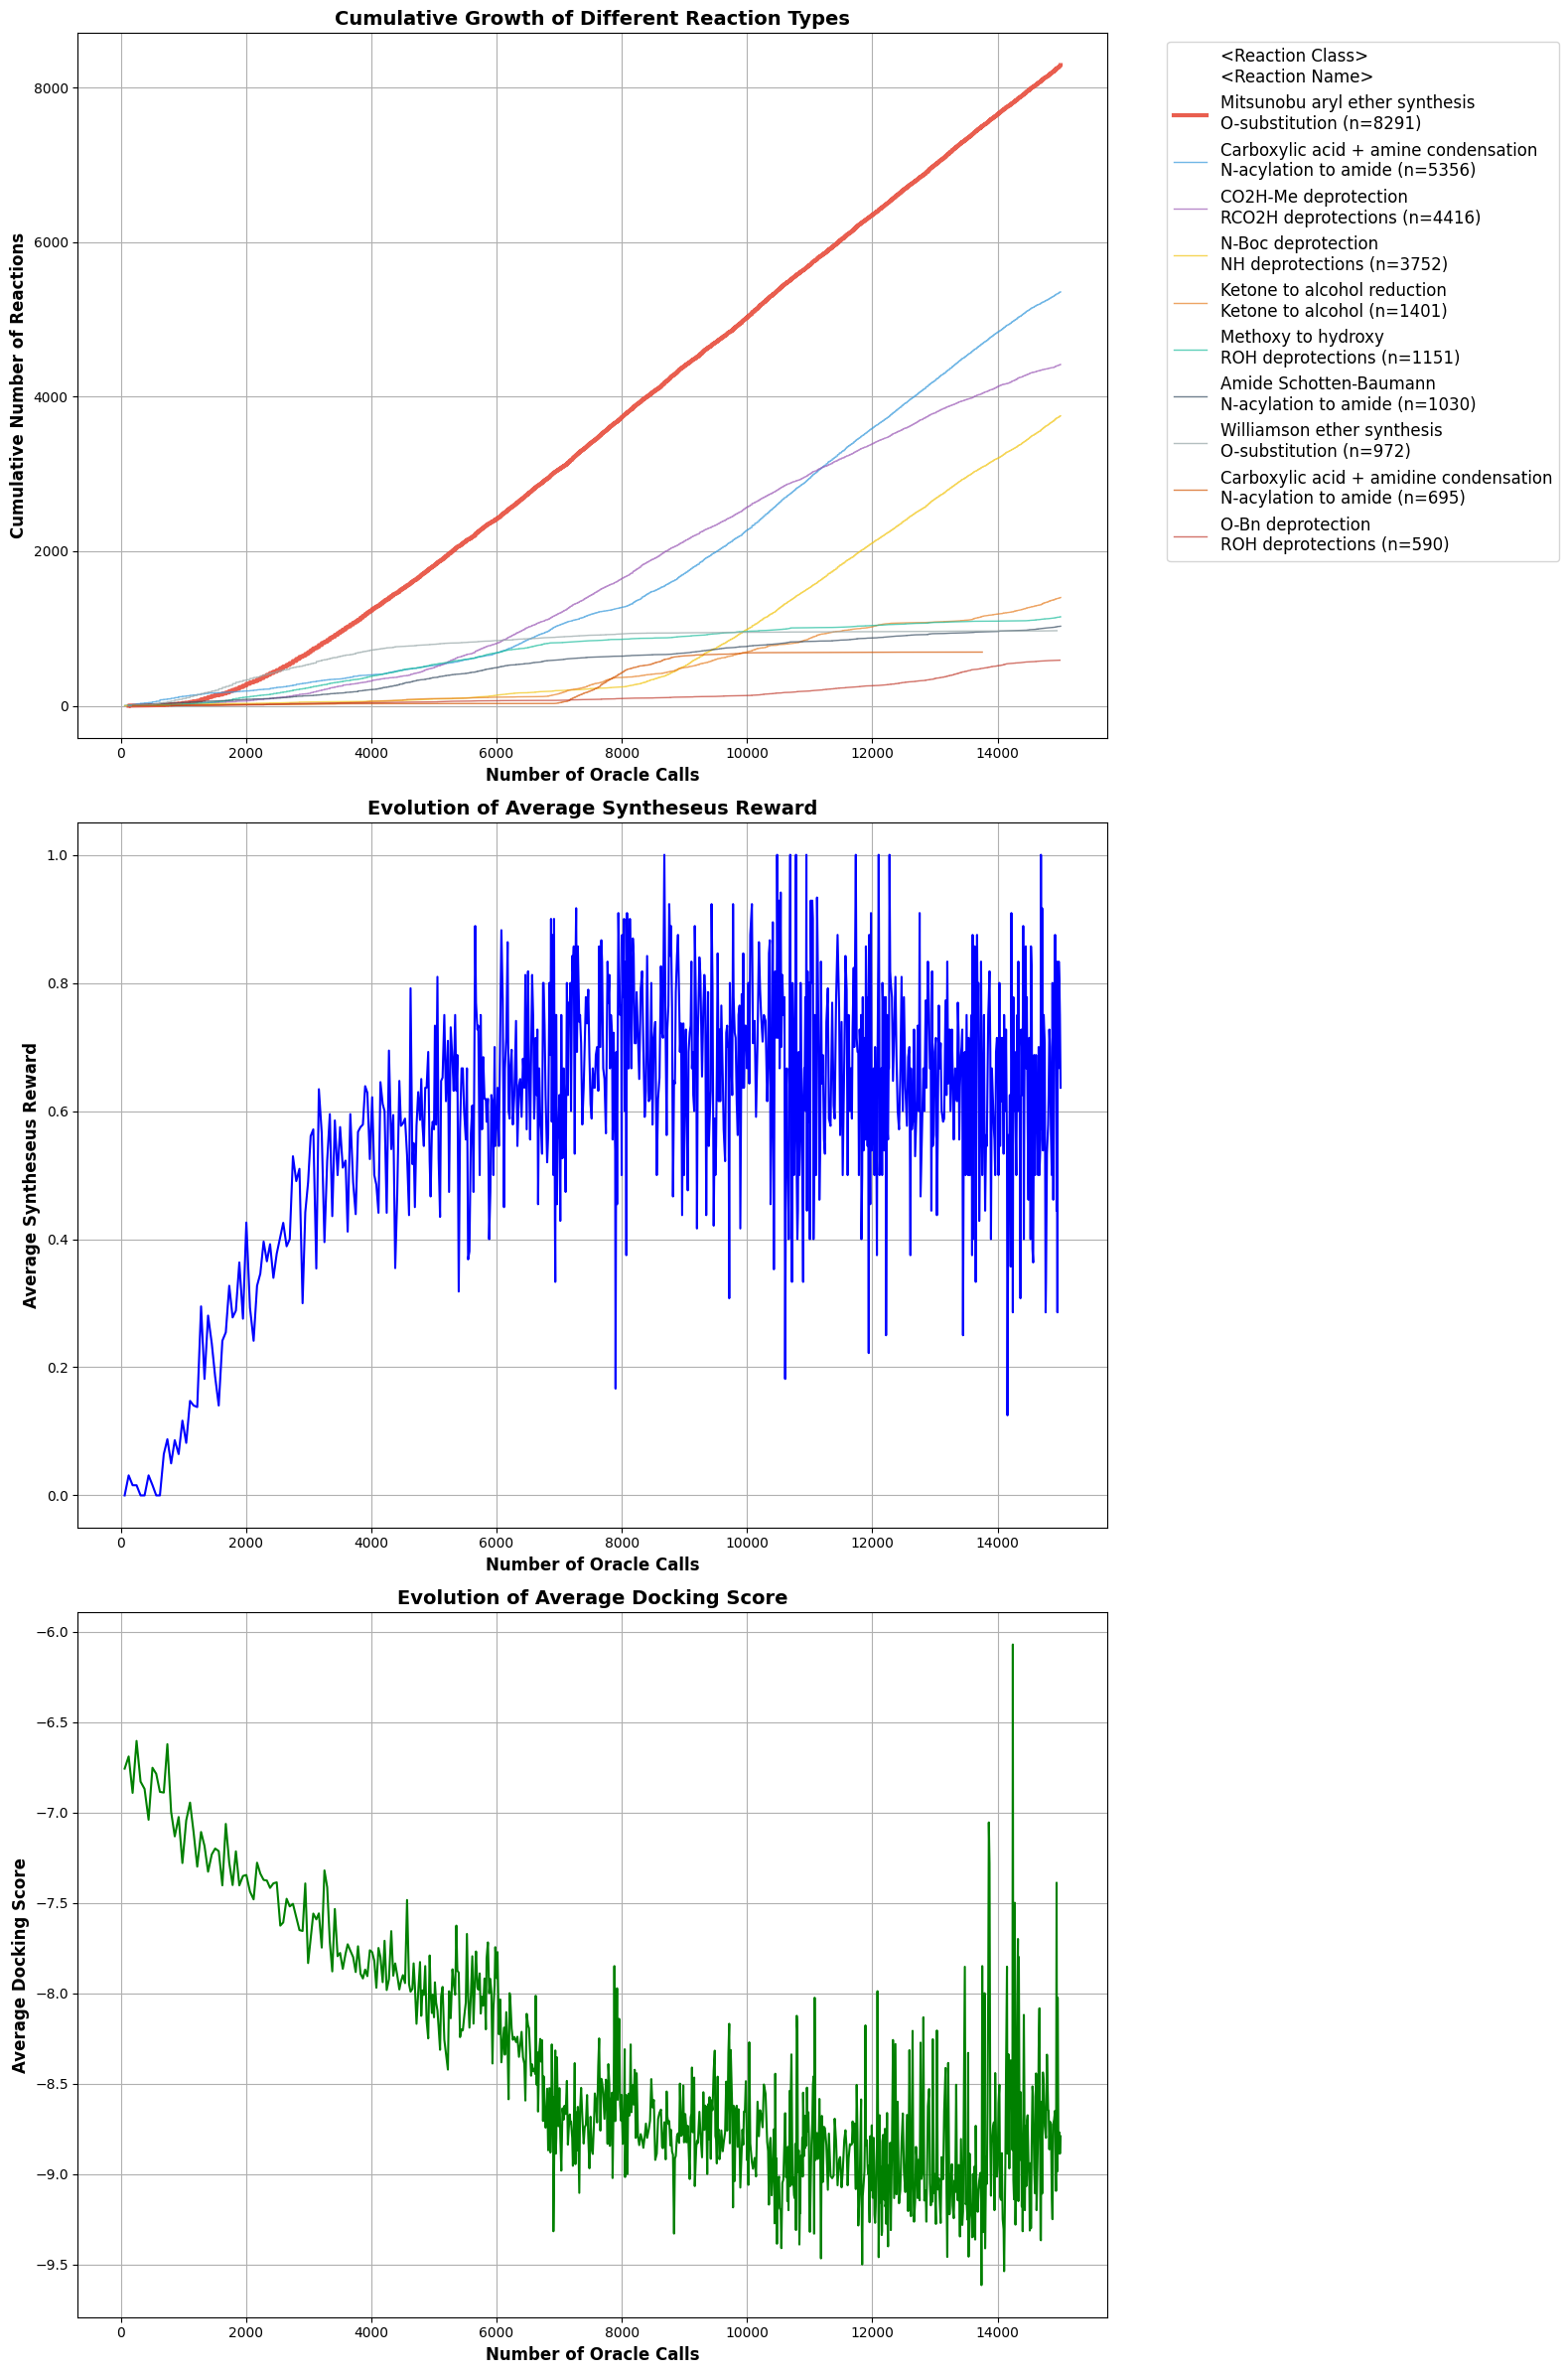

SMILES with no oracle call match: 0


In [28]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from collections import defaultdict

def canonicalize_smiles(smiles: str) -> str:
    """
    Canonicalize a SMILES string based on RDKit convention.
    """
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except Exception as e:
        return smiles

# Load data
enforced_rxn = "mitsunobu"
seed = 1
experiment_path = f"test_files/{enforced_rxn}/seed{seed}"
rxns = json.load(open(f"{experiment_path}/syntheseus_results/smiles_rxn_tracker.json"))
oracle_history = pd.read_csv(f"{experiment_path}/oracle_history.csv")
oracle_history["canonical_smiles"] = oracle_history["smiles"].apply(canonicalize_smiles)

# Track reactions by class over time
stats = defaultdict(list)
rxn_smiles = defaultdict(list)
no_match = 0

for smiles, rxn_info in rxns.items():
    try:
        oracle_call = int(oracle_history[(oracle_history["canonical_smiles"] == smiles)]["oracle_calls"].values[0])
    except IndexError:
        no_match += 1
        oracle_call = None
        
    for depth, info in rxn_info.items():
        rxn_class = info["rxn_class"]
        rxn_name = info["rxn_name"]
            
        if oracle_call is not None and rxn_class != "Unrecognized":
            stats[(rxn_class, rxn_name)].append(oracle_call)
            rxn_smiles[(rxn_class, rxn_name)].append(info["rxn_smiles"])

# Sort each reaction class by oracle calls
for rxn_class_name in stats:
    stats[rxn_class_name] = sorted(stats[rxn_class_name])

# Sort reaction classes by count in descending order
sorted_stats = sorted(stats.items(), key=lambda x: len(x[1]), reverse=True)

# Filter for reactions with count > 500 and take top 10
sorted_stats = [(k,v) for k,v in sorted_stats if len(v) > 500][:10]

# Define color palette - using a mix of muted and vibrant colors
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', 
          '#1abc9c', '#34495e', '#95a5a6', '#d35400', '#c0392b']
enforced_color = '#e74c3c'  # Bright red for enforced reaction

# Create figure with 3 vertically stacked subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 24))

# Plot 1: Cumulative reactions over time
ax1.plot([], [], ' ', label='<Reaction Class>\n<Reaction Name>')

for i, ((rxn_class, rxn_name), calls) in enumerate(sorted_stats):
    if enforced_rxn.lower() in rxn_class.lower() or enforced_rxn.lower() in rxn_name.lower():
        ax1.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=enforced_color, alpha=0.9, linewidth=3)
    else:
        ax1.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=colors[i], alpha=0.7, linewidth=1)

ax1.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax1.set_ylabel("Cumulative Number of Reactions", fontsize=12, fontweight="bold")
ax1.set_title("Cumulative Growth of Different Reaction Types", fontsize=14, fontweight="bold")
ax1.grid(True)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Plot 2: Average Syntheseus reward evolution
avg_syntheseus = oracle_history.groupby('oracle_calls')['syntheseus_reward'].mean().reset_index()
ax2.plot(avg_syntheseus['oracle_calls'], avg_syntheseus['syntheseus_reward'], color='blue')
ax2.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax2.set_ylabel("Average Syntheseus Reward", fontsize=12, fontweight="bold") 
ax2.set_title("Evolution of Average Syntheseus Reward", fontsize=14, fontweight="bold")
ax2.grid(True)

# Plot 3: Average Docking score evolution
avg_docking = oracle_history.groupby('oracle_calls')['quickvina2_gpu_raw_values'].mean().reset_index()
ax3.plot(avg_docking['oracle_calls'], avg_docking['quickvina2_gpu_raw_values'], color='green')
ax3.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax3.set_ylabel("Average Docking Score", fontsize=12, fontweight="bold")
ax3.set_title("Evolution of Average Docking Score", fontsize=14, fontweight="bold")
ax3.grid(True)

plt.tight_layout()
plt.show()

print(f"SMILES with no oracle call match: {no_match}")


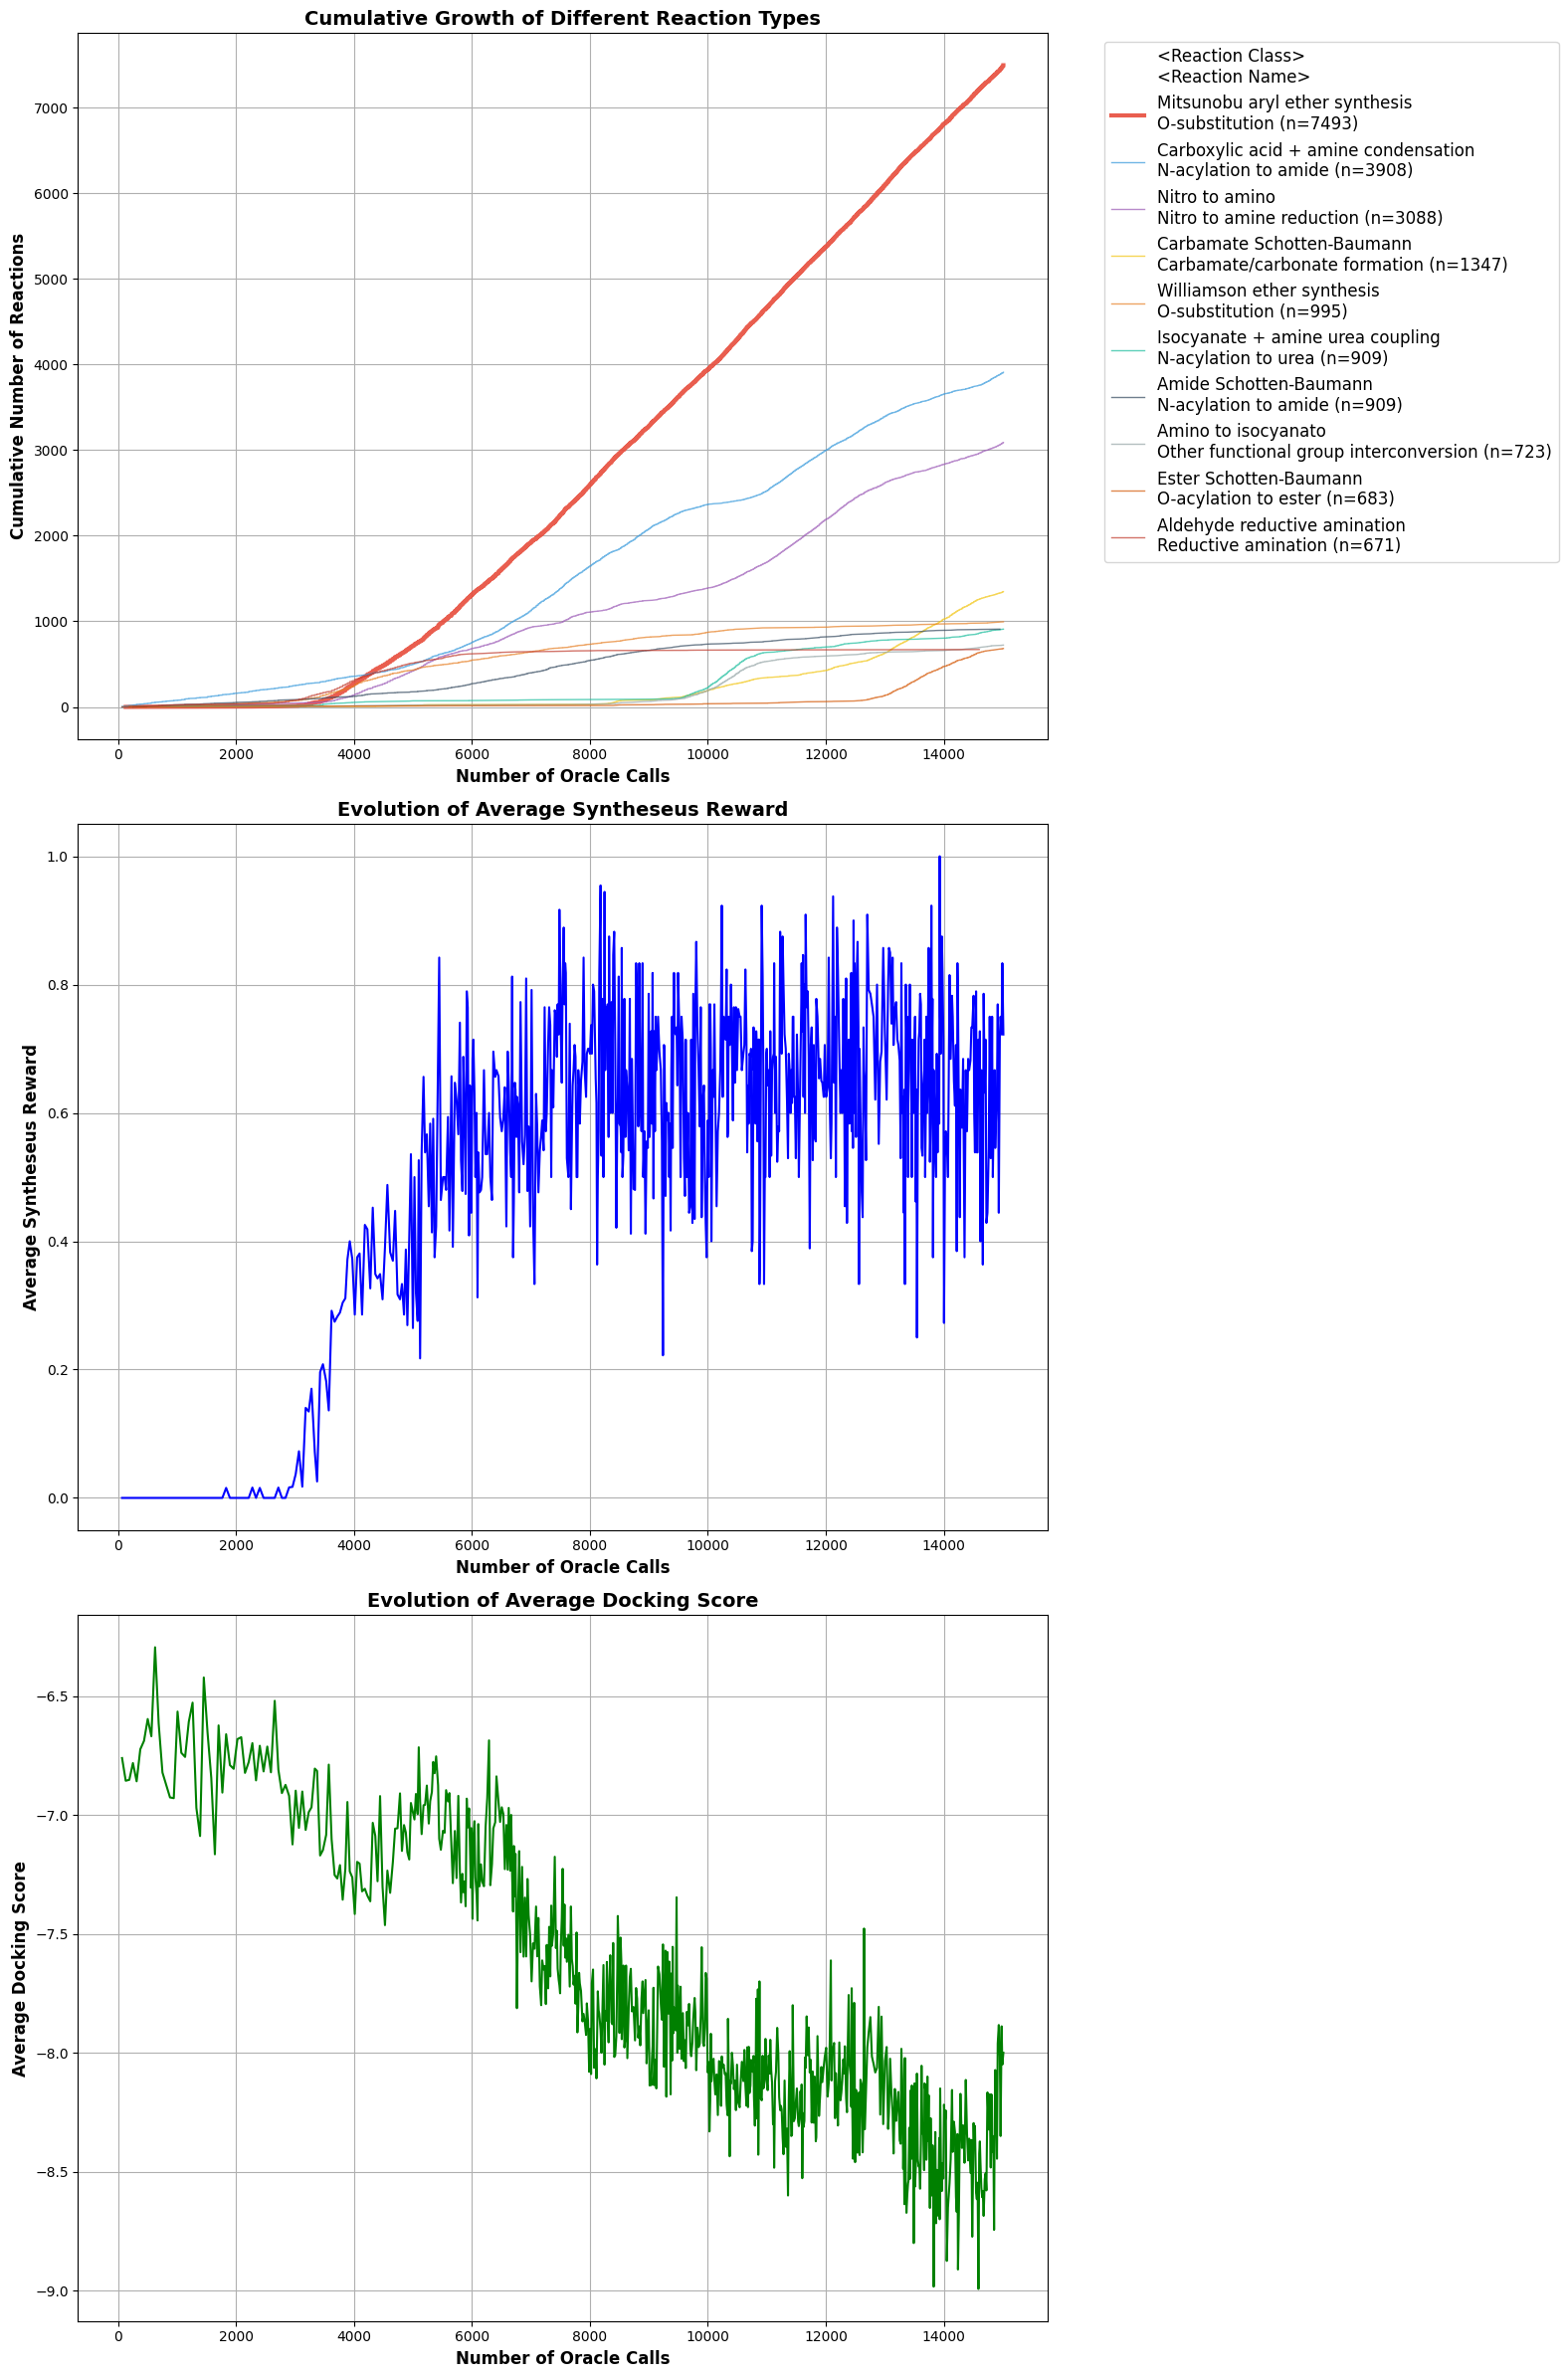

SMILES with no oracle call match: 0


In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from collections import defaultdict

def canonicalize_smiles(smiles: str) -> str:
    """
    Canonicalize a SMILES string based on RDKit convention.
    """
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except Exception as e:
        return smiles

# Load data
enforced_rxn = "mitsunobu"
seed = 2
experiment_path = f"test_files/{enforced_rxn}-avoid-deprotection/seed{seed}"
rxns = json.load(open(f"{experiment_path}/syntheseus_results/smiles_rxn_tracker.json"))
oracle_history = pd.read_csv(f"{experiment_path}/oracle_history.csv")
oracle_history["canonical_smiles"] = oracle_history["smiles"].apply(canonicalize_smiles)

# Track reactions by class over time
stats = defaultdict(list)
rxn_smiles = defaultdict(list)
no_match = 0

for smiles, rxn_info in rxns.items():
    try:
        oracle_call = int(oracle_history[(oracle_history["canonical_smiles"] == smiles)]["oracle_calls"].values[0])
    except IndexError:
        no_match += 1
        oracle_call = None
        
    for depth, info in rxn_info.items():
        rxn_class = info["rxn_class"]
        rxn_name = info["rxn_name"]
            
        if oracle_call is not None and rxn_class != "Unrecognized":
            stats[(rxn_class, rxn_name)].append(oracle_call)
            rxn_smiles[(rxn_class, rxn_name)].append(info["rxn_smiles"])

# Sort each reaction class by oracle calls
for rxn_class_name in stats:
    stats[rxn_class_name] = sorted(stats[rxn_class_name])

# Sort reaction classes by count in descending order
sorted_stats = sorted(stats.items(), key=lambda x: len(x[1]), reverse=True)

# Filter for reactions with count > 500 and take top 10
sorted_stats = [(k,v) for k,v in sorted_stats if len(v) > 500][:10]

# Define color palette - using a mix of muted and vibrant colors
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', 
          '#1abc9c', '#34495e', '#95a5a6', '#d35400', '#c0392b']
enforced_color = '#e74c3c'  # Bright red for enforced reaction

# Create figure with 3 vertically stacked subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 24))

# Plot 1: Cumulative reactions over time
ax1.plot([], [], ' ', label='<Reaction Class>\n<Reaction Name>')

for i, ((rxn_class, rxn_name), calls) in enumerate(sorted_stats):
    if enforced_rxn.lower() in rxn_class.lower() or enforced_rxn.lower() in rxn_name.lower():
        ax1.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=enforced_color, alpha=0.9, linewidth=3)
    else:
        ax1.plot(calls, range(1, len(calls)+1), 
                label=f"{rxn_class}\n{rxn_name} (n={len(calls)})", 
                color=colors[i], alpha=0.7, linewidth=1)

ax1.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax1.set_ylabel("Cumulative Number of Reactions", fontsize=12, fontweight="bold")
ax1.set_title("Cumulative Growth of Different Reaction Types", fontsize=14, fontweight="bold")
ax1.grid(True)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Plot 2: Average Syntheseus reward evolution
avg_syntheseus = oracle_history.groupby('oracle_calls')['syntheseus_reward'].mean().reset_index()
ax2.plot(avg_syntheseus['oracle_calls'], avg_syntheseus['syntheseus_reward'], color='blue')
ax2.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax2.set_ylabel("Average Syntheseus Reward", fontsize=12, fontweight="bold") 
ax2.set_title("Evolution of Average Syntheseus Reward", fontsize=14, fontweight="bold")
ax2.grid(True)

# Plot 3: Average Docking score evolution
avg_docking = oracle_history.groupby('oracle_calls')['quickvina2_gpu_raw_values'].mean().reset_index()
ax3.plot(avg_docking['oracle_calls'], avg_docking['quickvina2_gpu_raw_values'], color='green')
ax3.set_xlabel("Number of Oracle Calls", fontsize=12, fontweight="bold")
ax3.set_ylabel("Average Docking Score", fontsize=12, fontweight="bold")
ax3.set_title("Evolution of Average Docking Score", fontsize=14, fontweight="bold")
ax3.grid(True)

plt.tight_layout()
plt.show()

print(f"SMILES with no oracle call match: {no_match}")


[08:51:51] Unusual charge on atom 0 number of radical electrons set to zero
[08:52:04] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[08:52:46] Unusual charge on atom 0 number of radical electrons set to zero
[08:53:04] Unusual charge on atom 1 number of radical electrons set to zero
[08:54:20] Unusual charge on atom 0 number of radical electrons set to zero
[08:54:34] Unusual charge on atom 0 number of radical electrons set to zero
[08:55:08] WARNING: not removing hydrogen atom without neighbors
[08:55:19] Unusual charge on atom 0 number of radical electrons set to zero
[08:56:14] Unusual charge on atom 0 number of radical electrons set to zero
[08:57:05] Unusual charge on atom 0 number of radical electrons set to zero
[08:57:50] Unusual charge on atom 0 number of radical electrons set to zero
[08:59:05] WARNING: not removing hydrogen atom without neighbors
[08:59:28] WARNING: not removing hydrogen atom without neighbors
[08:59:3

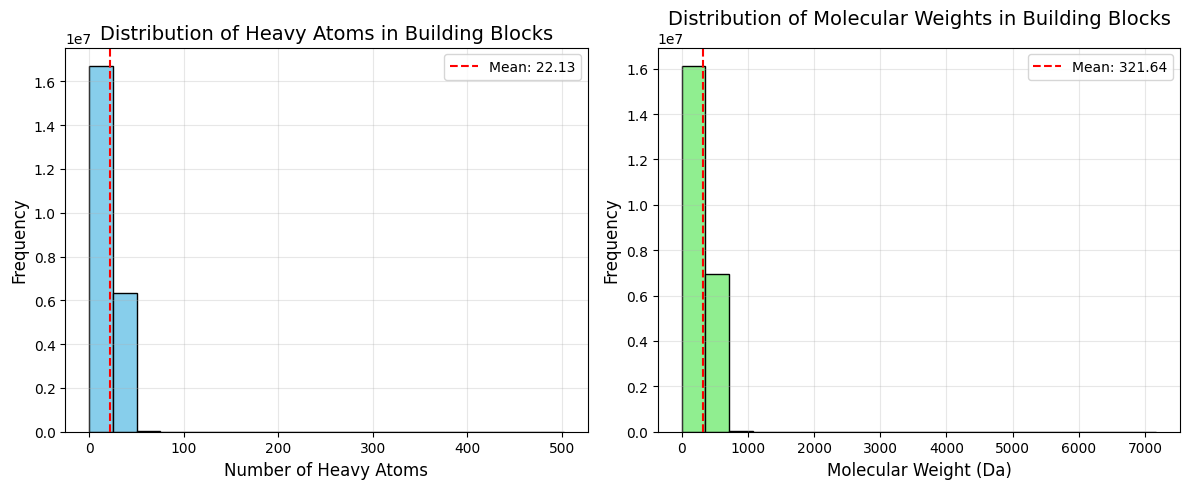

Total number of unique building blocks: 23077162


In [ ]:
# Extract all blocks from Suzuki reactions and canonicalize
from rdkit.Chem import AllChem

with open("../test/tango-rxn-stocks/emolecules-stock-no-isotopes.smi", "r") as f:
    blocks = f.readlines()

# Calculate heavy atoms and molecular weight for each block
from rdkit import Chem
from rdkit.Chem import Descriptors

block_props = []
for smiles in blocks:
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        heavy_atoms = mol.GetNumHeavyAtoms()
        mol_weight = Descriptors.MolWt(mol)
        block_props.append((heavy_atoms, mol_weight))

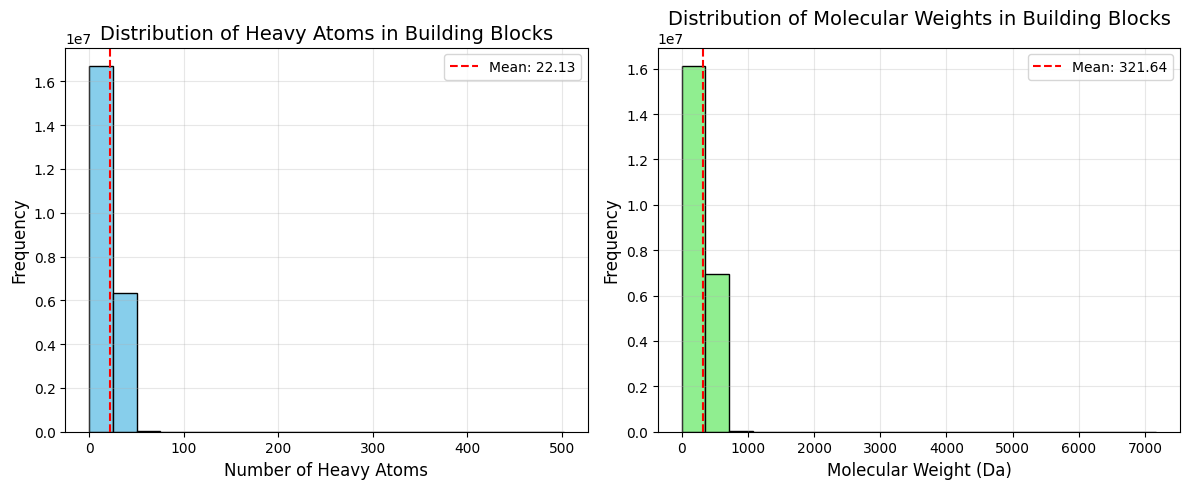

Total number of unique building blocks: 23077162


In [4]:
# Plot distributions
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Heavy atoms distribution
heavy_atoms = [prop[0] for prop in block_props]
ax1.hist(heavy_atoms, bins=20, color='skyblue', edgecolor='black')
ax1.set_xlabel('Number of Heavy Atoms', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Heavy Atoms in Building Blocks', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axvline(np.mean(heavy_atoms), color='red', linestyle='dashed', 
           label=f'Mean: {np.mean(heavy_atoms):.2f}')
ax1.legend()

# Molecular weight distribution
mol_weights = [prop[1] for prop in block_props]
ax2.hist(mol_weights, bins=20, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Molecular Weight (Da)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Molecular Weights in Building Blocks', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axvline(np.mean(mol_weights), color='red', linestyle='dashed',
           label=f'Mean: {np.mean(mol_weights):.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Total number of unique building blocks: {len(blocks)}")


In [35]:
with open("suzuki-blocks.smi", "w") as f:
    for block in blocks:
        f.write(f"{block}\n")

Statistical Significance Testing Results (Welch's t-test):

Heavy Atoms Comparison:
Dataset 1: 10.27 ± 4.66 (N=2052)
Dataset 2: 14.43 ± 4.76 (N=1355)
t-statistic: -25.1756
P-value: 0.0000000000
Statistically significant difference: Yes

Molecular Weight Comparison:
Dataset 1: 171.2 ± 67.6 (N=2052)
Dataset 2: 213.76 ± 59.59 (N=1355)
t-statistic: -19.3302
P-value: 0.0000000000
Statistically significant difference: Yes


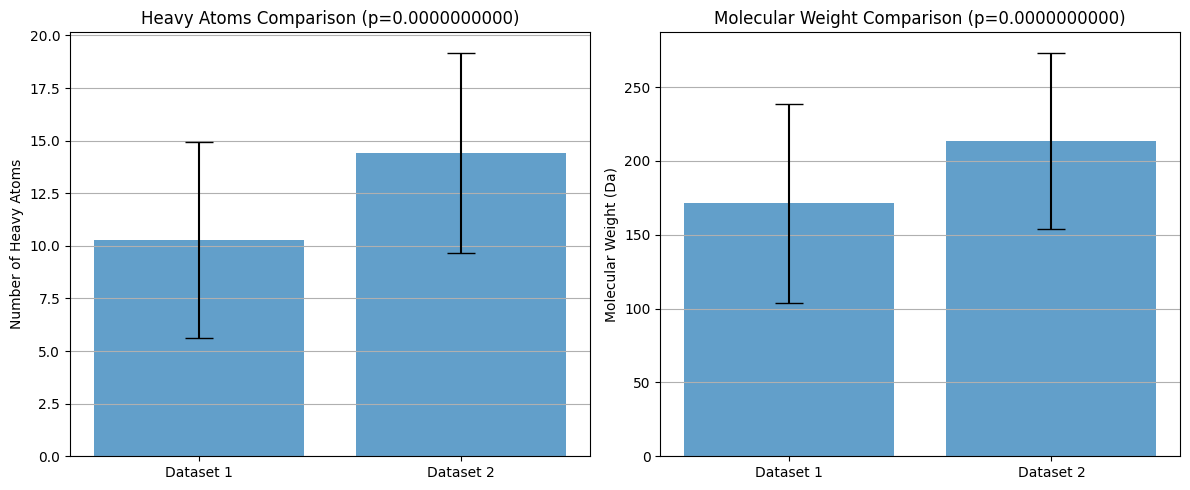


Effect Size (Cohen's d):
Heavy Atoms: 0.8832 - Large effect
Molecular Weight: 0.6679 - Medium effect


In [5]:
# Statistical significance testing for building block properties
import scipy.stats as stats

# Define the two datasets from the log file
dataset1 = {
    'name': 'Dataset 1',
    'n': 2052,
    'heavy_atoms_mean': 10.27,
    'heavy_atoms_std': 4.66,
    'mol_weight_mean': 171.2,
    'mol_weight_std': 67.6
}

dataset2 = {
    'name': 'Dataset 2',
    'n': 1355,
    'heavy_atoms_mean': 14.43,
    'heavy_atoms_std': 4.76,
    'mol_weight_mean': 213.76,
    'mol_weight_std': 59.59
}

# Perform Welch's t-test (t-test for independent samples without assuming equal variance)
# For heavy atoms
t_heavy, p_heavy = stats.ttest_ind_from_stats(
    dataset1['heavy_atoms_mean'], dataset1['heavy_atoms_std'], dataset1['n'],
    dataset2['heavy_atoms_mean'], dataset2['heavy_atoms_std'], dataset2['n'],
    equal_var=False  # Welch's t-test
)

# For molecular weight
t_weight, p_weight = stats.ttest_ind_from_stats(
    dataset1['mol_weight_mean'], dataset1['mol_weight_std'], dataset1['n'],
    dataset2['mol_weight_mean'], dataset2['mol_weight_std'], dataset2['n'],
    equal_var=False  # Welch's t-test
)

# Print results
print(f"Statistical Significance Testing Results (Welch's t-test):")
print(f"\nHeavy Atoms Comparison:")
print(f"{dataset1['name']}: {dataset1['heavy_atoms_mean']} ± {dataset1['heavy_atoms_std']} (N={dataset1['n']})")
print(f"{dataset2['name']}: {dataset2['heavy_atoms_mean']} ± {dataset2['heavy_atoms_std']} (N={dataset2['n']})")
print(f"t-statistic: {t_heavy:.4f}")
print(f"P-value: {p_heavy:.10f}")
print(f"Statistically significant difference: {'Yes' if p_heavy < 0.05 else 'No'}")

print(f"\nMolecular Weight Comparison:")
print(f"{dataset1['name']}: {dataset1['mol_weight_mean']} ± {dataset1['mol_weight_std']} (N={dataset1['n']})")
print(f"{dataset2['name']}: {dataset2['mol_weight_mean']} ± {dataset2['mol_weight_std']} (N={dataset2['n']})")
print(f"t-statistic: {t_weight:.4f}")
print(f"P-value: {p_weight:.10f}")
print(f"Statistically significant difference: {'Yes' if p_weight < 0.05 else 'No'}")

# Visualize the differences
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Heavy atoms comparison
datasets = [dataset1, dataset2]
x_pos = np.arange(len(datasets))
means = [d['heavy_atoms_mean'] for d in datasets]
errors = [d['heavy_atoms_std'] for d in datasets]
names = [d['name'] for d in datasets]

ax1.bar(x_pos, means, yerr=errors, align='center', alpha=0.7, ecolor='black', capsize=10)
ax1.set_ylabel('Number of Heavy Atoms')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names)
ax1.set_title(f'Heavy Atoms Comparison (p={p_heavy:.10f})')
ax1.yaxis.grid(True)

# Molecular weight comparison
means = [d['mol_weight_mean'] for d in datasets]
errors = [d['mol_weight_std'] for d in datasets]

ax2.bar(x_pos, means, yerr=errors, align='center', alpha=0.7, ecolor='black', capsize=10)
ax2.set_ylabel('Molecular Weight (Da)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(names)
ax2.set_title(f'Molecular Weight Comparison (p={p_weight:.10f})')
ax2.yaxis.grid(True)

plt.tight_layout()
plt.show()

# Effect size calculation (Cohen's d)
def cohens_d(mean1, std1, mean2, std2):
    # Pooled standard deviation
    pooled_std = np.sqrt(((std1**2 + std2**2) / 2))
    # Cohen's d
    d = abs(mean1 - mean2) / pooled_std
    return d

d_heavy = cohens_d(
    dataset1['heavy_atoms_mean'], dataset1['heavy_atoms_std'],
    dataset2['heavy_atoms_mean'], dataset2['heavy_atoms_std']
)

d_weight = cohens_d(
    dataset1['mol_weight_mean'], dataset1['mol_weight_std'],
    dataset2['mol_weight_mean'], dataset2['mol_weight_std']
)

print("\nEffect Size (Cohen's d):")
print(f"Heavy Atoms: {d_heavy:.4f} - {'Small' if d_heavy < 0.5 else 'Medium' if d_heavy < 0.8 else 'Large'} effect")
print(f"Molecular Weight: {d_weight:.4f} - {'Small' if d_weight < 0.5 else 'Medium' if d_weight < 0.8 else 'Large'} effect")

